# Module 1 — EAT-26 Risk Pattern Classifier

**Goal:** predict a symptom "risk pattern" (Low Risk / Restrictive-AN-type / Bulimic-BN-type / Binge-BED-type) from EAT-26-style screening scores, using ML.

**Scope note:** EAT-26 is a validated *screening* tool, not a diagnostic one. Real, respondent-level EAT-26 data isn't publicly available (it's sensitive health data), so this dataset is **synthetic** — generated to follow published EAT-26 subscale patterns (Garner et al., 1982) rather than copied from real patients. This is a portfolio ML pipeline demo, not a clinical tool.

## 1. Generate the synthetic dataset

In [1]:
import sys, os
from pathlib import Path

# walk up from wherever we are until we find the project root (marked by README.md)
p = Path.cwd()
while not (p / "README.md").exists() and p != p.parent:
    p = p.parent

os.chdir(p)
if str(p / "src") not in sys.path:
    sys.path.insert(0, str(p / "src"))

print("Working directory set to:", os.getcwd())

Working directory set to: c:\PROJECTSSSSS\uk-ed-analytics


In [2]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from generate_eat26_dataset import main as generate_data
generate_data()

Generated 3000 synthetic rows -> data/processed/eat26_synthetic.csv
risk_label
Low Risk                 1400
Binge (BED-type)          650
Restrictive (AN-type)     500
Bulimic (BN-type)         450
Name: count, dtype: int64
   age  gender bmi_category  dieting_score  bulimia_food_preoccupation_score  \
0   22  Female  Underweight             29                                10   
1   30  Female       Normal             10                                 0   
2   14  Female       Normal             27                                 8   
3   21  Female  Underweight              6                                 3   
4   37    Male   Overweight              9                                 7   

   oral_control_score  total_eat26_score             risk_label  
0                   6                 45  Restrictive (AN-type)  
1                   5                 15               Low Risk  
2                  11                 46  Restrictive (AN-type)  
3                   1         

In [3]:
df = pd.read_csv('data/processed/eat26_synthetic.csv')
df.head()

,age,gender,bmi_category,dieting_score,bulimia_food_preoccupation_score,oral_control_score,total_eat26_score,risk_label
0,22,Female,Underweight,29,10,6,45,Restrictive (AN-type)
1,30,Female,Normal,10,0,5,15,Low Risk
2,14,Female,Normal,27,8,11,46,Restrictive (AN-type)
3,21,Female,Underweight,6,3,1,10,Low Risk
4,37,Male,Overweight,9,7,6,22,Binge (BED-type)


## 2. Exploratory analysis

How do the three EAT-26 subscales (Dieting, Bulimia & Food Preoccupation, Oral Control) differ across the four risk patterns?

In [4]:
df['risk_label'].value_counts()

risk_label
Low Risk                 1400
Binge (BED-type)          650
Restrictive (AN-type)     500
Bulimic (BN-type)         450
Name: count, dtype: int64

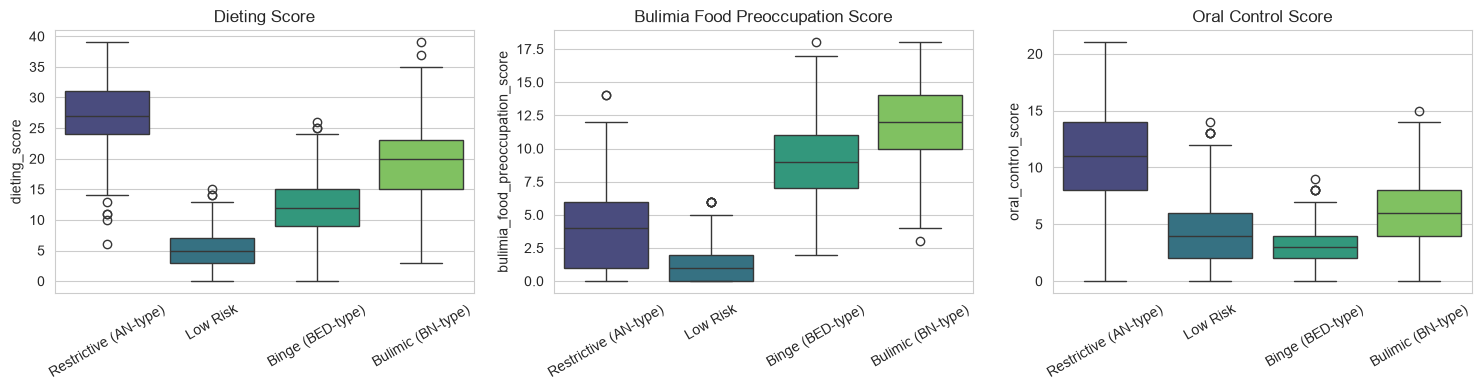

In [5]:
import seaborn as sns
sns.set_style('whitegrid')

subscales = ['dieting_score', 'bulimia_food_preoccupation_score', 'oral_control_score']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, subscales):
    sns.boxplot(data=df, x='risk_label', y=col, ax=ax, hue='risk_label', palette='viridis', legend=False)
    ax.set_title(col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Reading this:** Restrictive (AN-type) has the highest Dieting scores but moderate Oral Control. Bulimic (BN-type) has the highest Bulimia/Food-Preoccupation scores paired with low Oral Control. Binge (BED-type) has the *lowest* Oral Control of all — consistent with impulse-control difficulty — but lower Dieting severity than the restrictive pattern. This separation is what the classifier learns from.

## 3. Train and evaluate classifiers

In [6]:
from eat26_classifier import load_data, train_and_evaluate, feature_importance

df = load_data()
rf_pipe, rf_acc, rf_f1 = train_and_evaluate(df, 'random_forest')


=== random_forest ===
Accuracy: 0.943
Macro F1: 0.923

                       precision    recall  f1-score   support

     Binge (BED-type)       0.92      0.86      0.89       130
    Bulimic (BN-type)       0.84      0.86      0.85        90
             Low Risk       0.99      1.00      0.99       280
Restrictive (AN-type)       0.95      0.98      0.97       100

             accuracy                           0.94       600
            macro avg       0.92      0.92      0.92       600
         weighted avg       0.94      0.94      0.94       600



In [7]:
lr_pipe, lr_acc, lr_f1 = train_and_evaluate(df, 'logistic_regression')

print(f"Random Forest       -> Accuracy: {rf_acc:.3f} | Macro F1: {rf_f1:.3f}")
print(f"Logistic Regression -> Accuracy: {lr_acc:.3f} | Macro F1: {lr_f1:.3f}")


=== logistic_regression ===
Accuracy: 0.943
Macro F1: 0.921

                       precision    recall  f1-score   support

     Binge (BED-type)       0.91      0.88      0.89       130
    Bulimic (BN-type)       0.83      0.83      0.83        90
             Low Risk       0.99      1.00      0.99       280
Restrictive (AN-type)       0.95      0.97      0.96       100

             accuracy                           0.94       600
            macro avg       0.92      0.92      0.92       600
         weighted avg       0.94      0.94      0.94       600

Random Forest       -> Accuracy: 0.943 | Macro F1: 0.923
Logistic Regression -> Accuracy: 0.943 | Macro F1: 0.921


## 4. What drives the predictions?

Saved feature importance plot to reports/figures/feature_importance.png


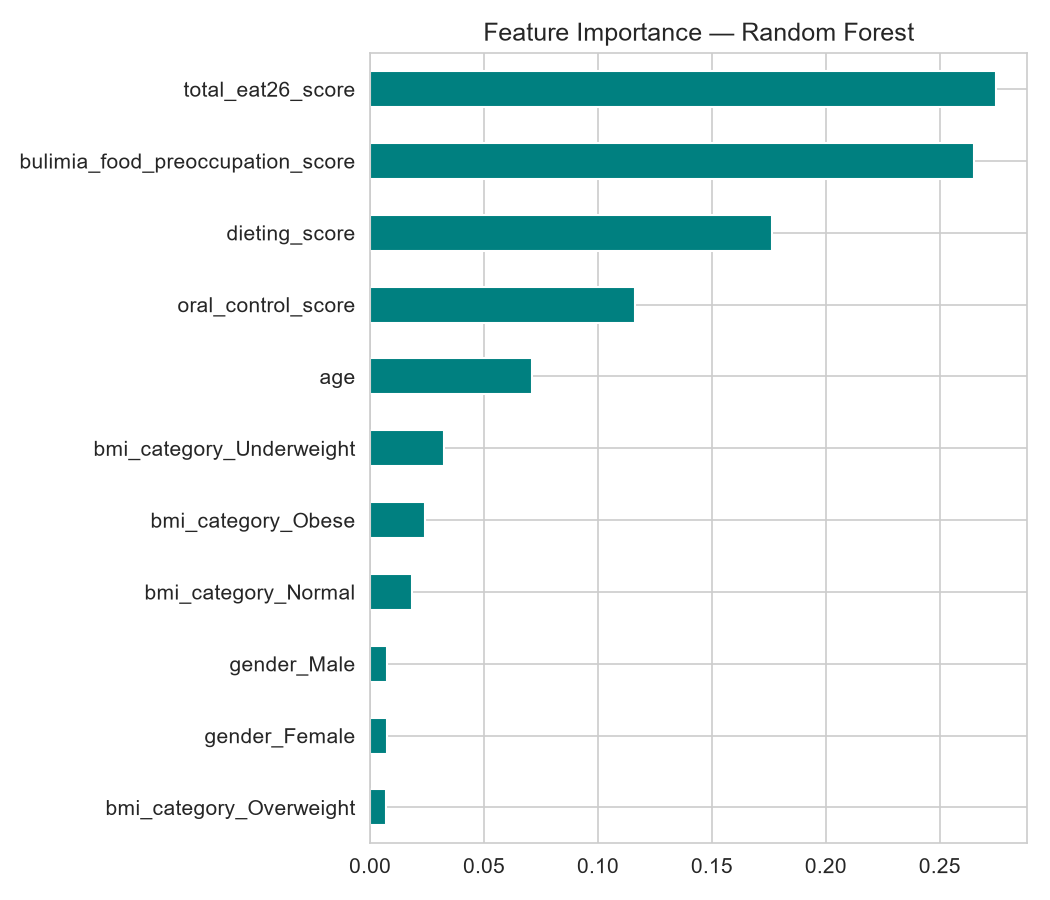

In [8]:
feature_importance(rf_pipe, df)
from IPython.display import Image
Image('reports/figures/feature_importance.png')

## Takeaways

- Both models hit ~94% accuracy / 0.92 macro F1 on the synthetic test set
- Confusion is concentrated between **Bulimic** and **Binge** patterns — which mirrors real clinical difficulty, since both share elevated Bulimia/Food-Preoccupation scores; Dieting severity is the main separator
- Oral Control score is the single most important feature — matches the literature's emphasis on impulse control as a key differentiator for binge-type presentations

